In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2925,2025-09-21 03:01:00,click,46,Women,Vogue Women Pink Sunglasses,vogue,4930.0,4437.0,...,Pink,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>This stylish range of vogue sunglasses are ...
1,1,2290,2025-09-21 03:02:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1950.0,1755.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
2,1,1287,2025-09-21 03:05:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1450.0,1305.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
3,1,7226,2025-09-21 03:04:00,click,46,Women,Miami Blues Women Sunglasses,Miami Blues,915.0,713.0,...,Purple,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>NA</p>
4,1,868,2025-09-21 03:17:00,click,46,Women,United Colors of Benetton Women Sunglass,United Colors of Benetton,3450.0,3105.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p><span style=""color: #000000 font-family;"">..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,4126,1,5,"[0, 0, 0, 0, 0]","[FILA, HM, Rocia, Rocia, Catwalk]","[Men, Women, Women, Women, Women]","[Adults-Men, Adults-Women, Adults-Women, Adult...","[Navy Blue, Multi, Black, White, Black]","[Summer, Winter, Winter, Winter, Winter]","[2012, 2012, 2012, 2012, 2015]","[Sports, Casual, Casual, Casual, Casual]","[Apparel, Footwear, Footwear, Footwear, Footwear]","[Bottomwear, Shoes, Shoes, Shoes, Shoes]","[Shorts, Flats, Flats, Flats, Flats]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, Everyday, Casual, <UNK>, Casual]","[click, click, click, click, click]","[9457, 5382, 8022, 5748, 2363]","[5382, 8022, 5748, 2363, 9928]"
1,4126,2,5,"[0, 0, 0, 0, 0]","[Proline, FILA, HM, Rocia, Rocia]","[Men, Men, Women, Women, Women]","[Adults-Men, Adults-Men, Adults-Women, Adults-...","[Grey Melange, Navy Blue, Multi, Black, White]","[Summer, Summer, Winter, Winter, Winter]","[2012, 2012, 2012, 2012, 2012]","[Sports, Sports, Casual, Casual, Casual]","[Apparel, Apparel, Footwear, Footwear, Footwear]","[Bottomwear, Bottomwear, Shoes, Shoes, Shoes]","[Shorts, Shorts, Flats, Flats, Flats]","[Regular Fit, <UNK>, <UNK>, <UNK>, <UNK>]","[Sports, <UNK>, Everyday, Casual, <UNK>]","[click, click, click, click, click]","[2532, 9457, 5382, 8022, 5748]","[9457, 5382, 8022, 5748, 2363]"
2,4126,3,5,"[0, 0, 0, 0, 0]","[Proline, Proline, FILA, HM, Rocia]","[Men, Men, Men, Women, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Wo...","[Charcoal, Grey Melange, Navy Blue, Multi, Black]","[Summer, Summer, Summer, Winter, Winter]","[2013, 2012, 2012, 2012, 2012]","[Sports, Sports, Sports, Casual, Casual]","[Apparel, Apparel, Apparel, Footwear, Footwear]","[Bottomwear, Bottomwear, Bottomwear, Shoes, Sh...","[Shorts, Shorts, Shorts, Flats, Flats]","[Regular Fit, Regular Fit, <UNK>, <UNK>, <UNK>]","[Sports, Sports, <UNK>, Everyday, Casual]","[wishlist, click, click, click, click]","[7362, 2532, 9457, 5382, 8022]","[2532, 9457, 5382, 8022, 5748]"
4,4126,5,5,"[0, 0, 0, 0, 0]","[Rocia, Catwalk, Titan, Fastrack, ESPRIT]","[Women, Women, Men, Men, Men]","[Adults-Women, Adults-Women, Adults-Men, Adult...","[White, Black, Black, Black, Steel]","[Winter, Winter, Winter, Winter, Winter]","[2012, 2015, 2016, 2016, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Accessories, Accessories,...","[Shoes, Shoes, Watches, Watches, Watches]","[Flats, Flats, Watches, Watches, Watches]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, Casual, <UNK>, <UNK>, <UNK>]","[click, click, cart, click, click]","[5748, 2363, 9928, 3327, 9961]","[2363, 9928, 3327, 9961, 2856]"
5,4126,6,5,"[0, 0, 0, 0, 0]","[Rocia, Rocia, Catwalk, Titan, Fastrack]","[Women, Women, Women, Men, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Black, White, Black, Black, Black]","[Winter, Winter, Winter, Winter, Winter]","[2012, 2012, 2015, 2016, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Accessories, Ac...","[Shoes, Shoes, Shoes, Watches, Watches]","[Flats, Flats, Flats, Watches, Watches]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, <UNK>, Casual, <UNK>, <UNK>]","[click, click, click, cart, click]","[8022, 5748, 2363, 9928, 3327]","[5748, 2363, 9928, 3327, 9961]"
6,4126,7,5,"[0, 0, 0, 0, 0]","[HM, Rocia, Rocia, Catwalk, Titan]","[Women, Women, Women, Women, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Multi, Black, White, Black, Black]","[Winter, Winter, Winter, Winter, Winter]","[2012, 2012, 2012, 2015, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Acces...","[Shoes, Shoes, Shoes, Shoes, Watches]","[Flats, Flats, Flats, Flats, Watches]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Everyday, Casual, <UNK>, Casual, <UNK>]","[click, click, click, click, cart]","[5382, 8022, 5748, 2363, 9928]","[8022, 5748, 2363, 9928,

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 4126,
 'user_rn': 15,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Catwalk', 'Skechers', 'Citizen', 'Fossil', 'Fossil'],
 'gender': ['Women', 'Women', 'Men', 'Men', 'Men'],
 'age_group': ['Adults-Women',
  'Adults-Women',
  'Adults-Men',
  'Adults-Men',
  'Adults-Men'],
 'base_color': ['Black', 'Green', 'Black', 'Black', 'Brown'],
 'season': ['Winter', 'Winter', 'Winter', 'Winter', 'Winter'],
 'year': ['2015', '2015', '2016', '2016', '2016'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Footwear',
  'Footwear',
  'Accessories',
  'Accessories',
  'Accessories'],
 'sub_category': ['Shoes', 'Shoes', 'Watches', 'Watches', 'Watches'],
 'article_type': ['Casual Shoes',
  'Casual Shoes',
  'Watches',
  'Watches',
  'Watches'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['Everyday', 'Everyday', 'Casual', 'Casual', 'Casual'],
 'action': ['click', 'click', 'click', 'click', 'click'],
 'item_id': [9802, 6620

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'click', 'click', 'click', 'click'],
 'age_group': ['Adults-Women',
               'Adults-Women',
               'Adults-Men',
               'Adults-Men',
               'Adults-Men'],
 'article_type': ['Casual Shoes',
                  'Casual Shoes',
                  'Watches',
                  'Watches',
                  'Watches'],
 'base_color': ['Black', 'Green', 'Black', 'Black', 'Brown'],
 'brand_name': ['Catwalk', 'Skechers', 'Citizen', 'Fossil', 'Fossil'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Women', 'Women', 'Men', 'Men', 'Men'],
 'master_category': ['Footwear',
                     'Footwear',
                     'Accessories',
                     'Accessories',
                     'Accessories'],
 'occasion': ['Everyday', 'Everyday', 'Casual', 'Casual', 'Casual'],
 'season': ['Winter', 'Winter', 'Winter', 'Winter', 'Winter'],
 'sub_category': ['Shoes', 'Shoes', 'Watches', 'Watches', 'Watches'],
 'usage': ['Casual'

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

{'inputs': {'feature_sequences': {'action': tensor([[3, 3, 3, 3, 3]], dtype=torch.int32),
                                  'age_group': tensor([[4, 4, 2, 2, 2]], dtype=torch.int32),
                                  'article_type': tensor([[ 16,  16, 120, 120, 120]], dtype=torch.int32),
                                  'base_color': tensor([[ 3, 14,  3,  3,  6]], dtype=torch.int32),
                                  'brand_name': tensor([[ 62, 288,  67, 116, 116]], dtype=torch.int32),
                                  'fit': tensor([[1, 1, 1, 1, 1]], dtype=torch.int32),
                                  'gender': tensor([[6, 6, 4, 4, 4]], dtype=torch.int32),
                                  'master_category': tensor([[4, 4, 2, 2, 2]], dtype=torch.int32),
                                  'occasion': tensor([[6, 6, 2, 2, 2]], dtype=torch.int32),
                                  'season': tensor([[5, 5, 5, 5, 5]], dtype=torch.int32),
                                  'sub_category': 

# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{1543: 0.31580084562301636,
 9994: 0.3107038736343384,
 2337: 0.3064002990722656,
 7467: 0.30532604455947876,
 6119: 0.30311083793640137,
 1271: 0.3031095266342163,
 935: 0.3020637631416321,
 9281: 0.30147284269332886,
 8076: 0.3009800314903259,
 6873: 0.30094730854034424,
 7827: 0.29885774850845337,
 1439: 0.29859423637390137,
 3135: 0.29784321784973145,
 5127: 0.29642218351364136,
 2199: 0.2943457365036011,
 2707: 0.2918635606765747,
 1363: 0.28943419456481934,
 6599: 0.2891276478767395,
 5160: 0.2890733480453491,
 1564: 0.28706032037734985,
 1442: 0.2858662009239197,
 8483: 0.28514373302459717,
 2929: 0.2837020754814148,
 2476: 0.28356289863586426,
 8743: 0.2832843065261841,
 2412: 0.2832462787628174,
 7305: 0.282975435256958,
 9923: 0.28284335136413574,
 8681: 0.28278589248657227,
 977: 0.28263795375823975}

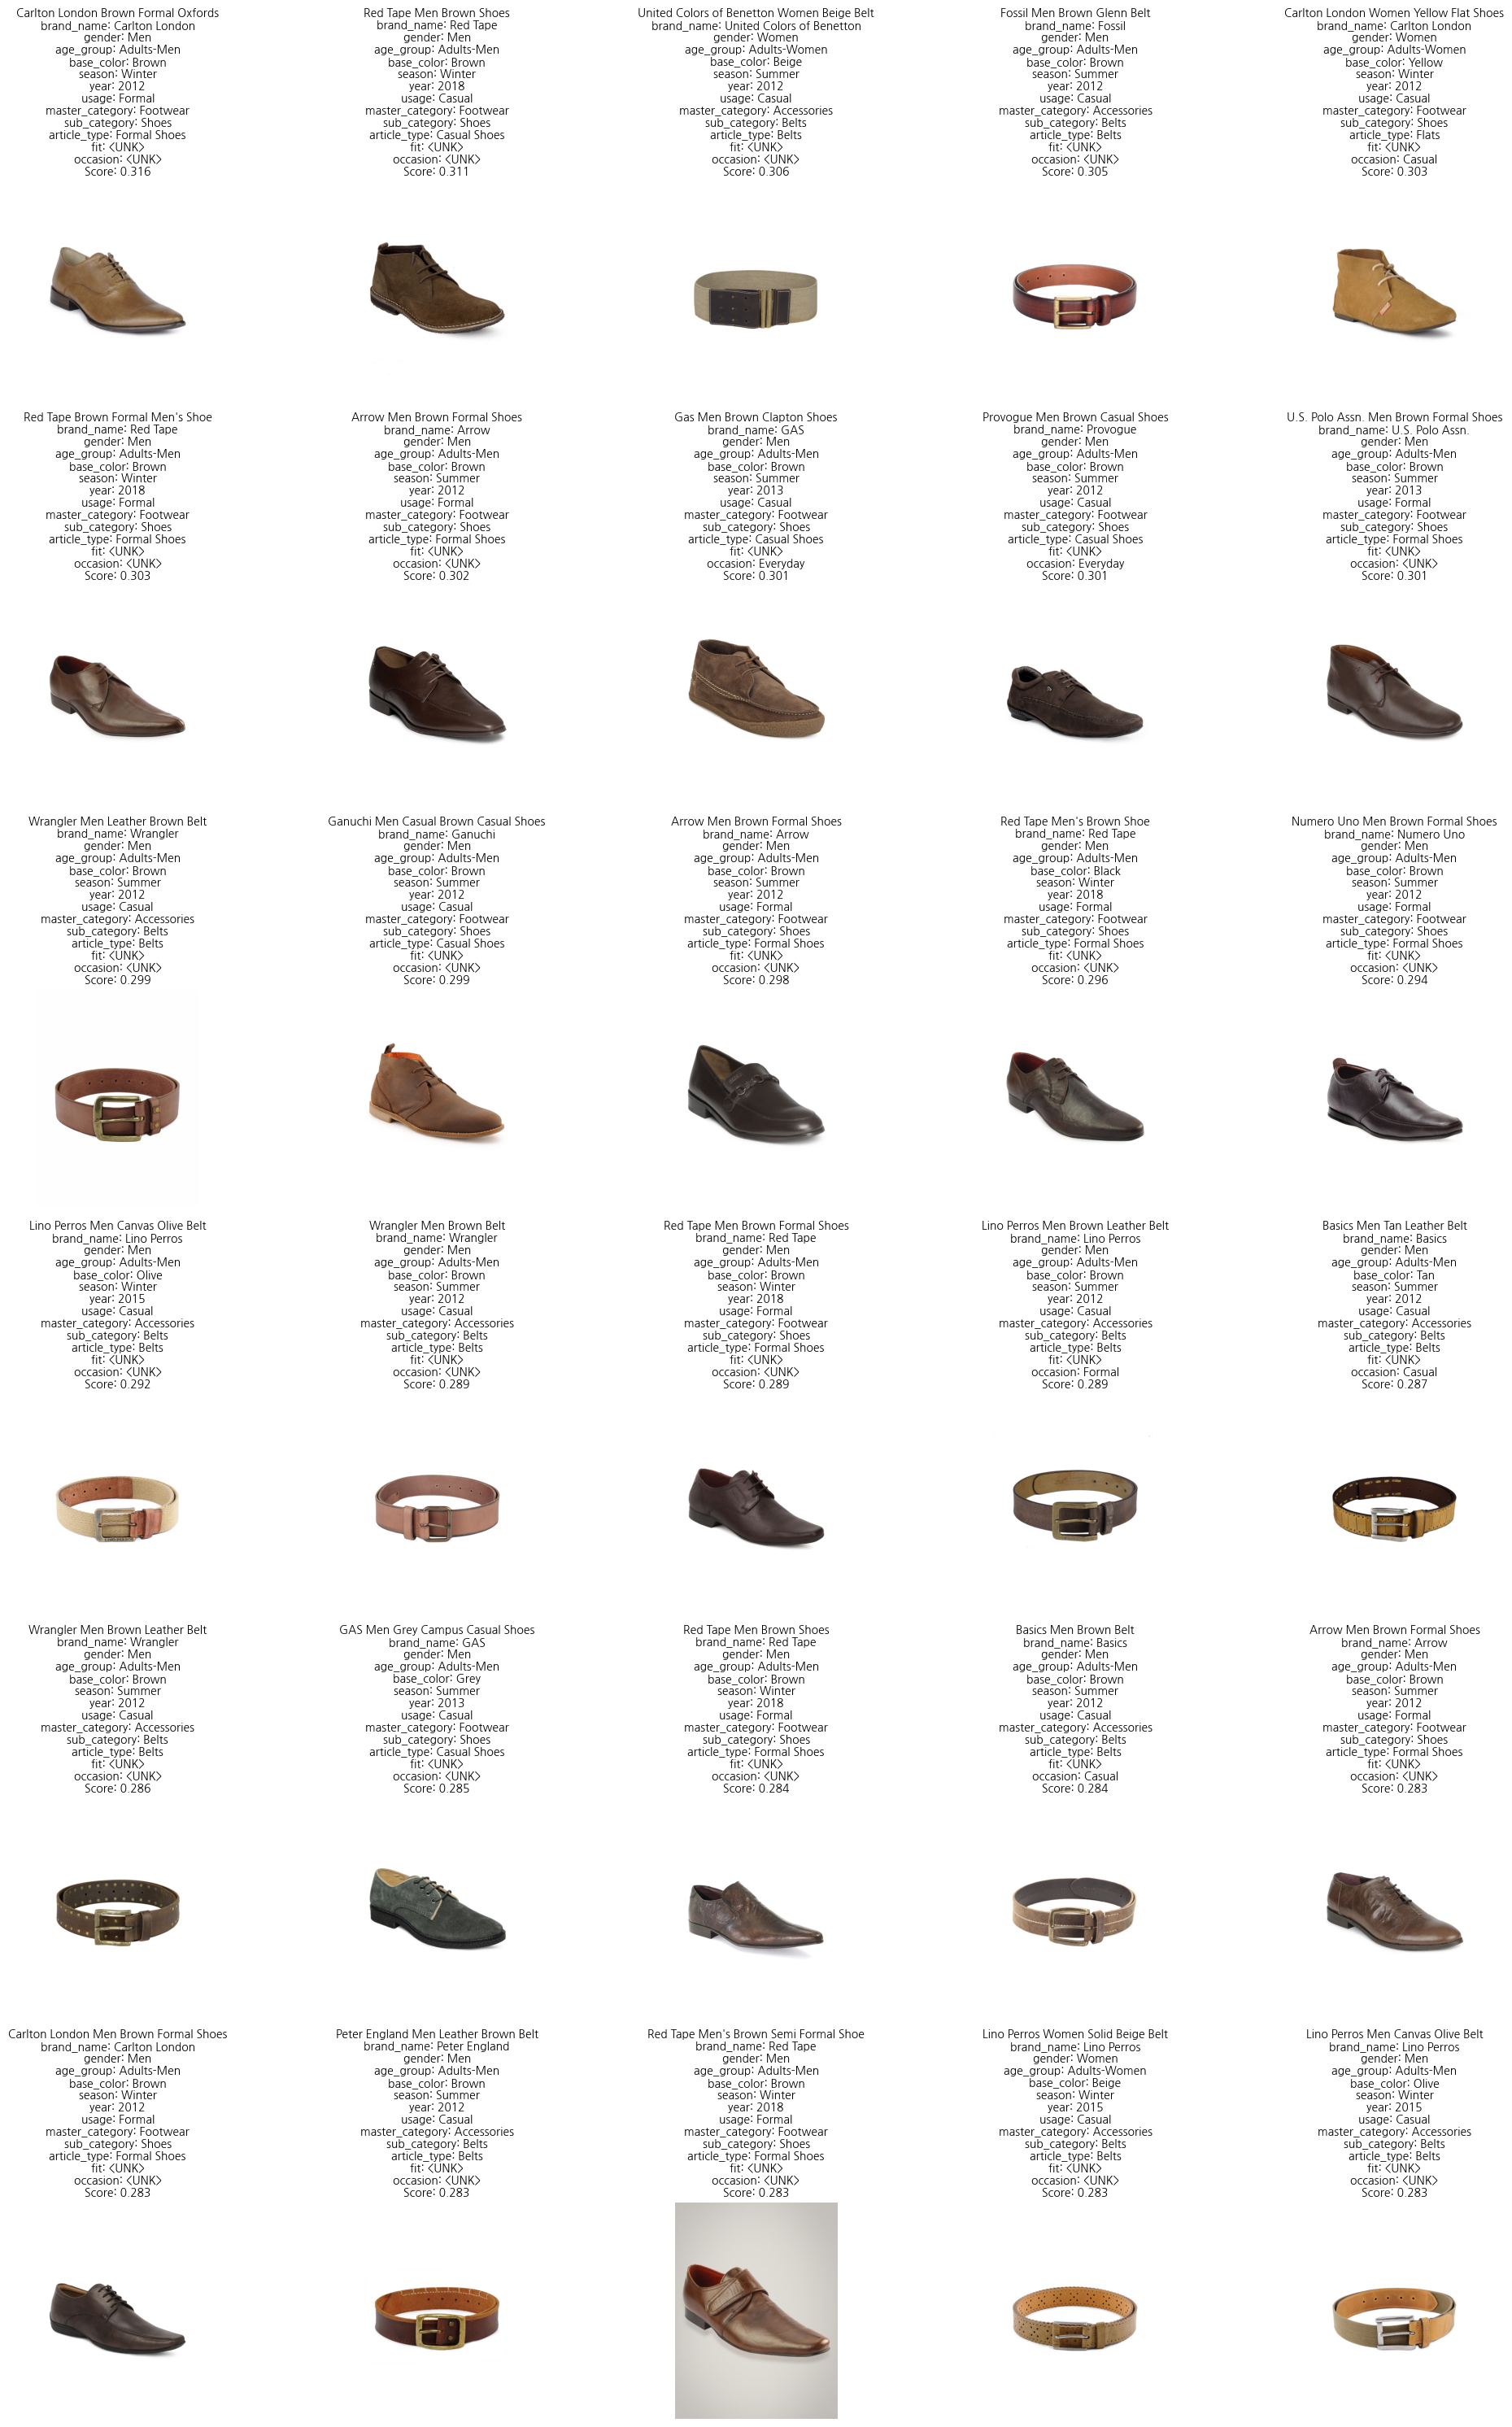

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.base_path.joinpath("images"),
)